## Batch Gradient Descent

In [1]:
import numpy as np
import pandas as pd
import time

In [22]:
df = pd.read_csv("D:\Deep_Learning\Dataset\Social_Network_Ads.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\CSN\AppData\Local\Temp\ipykernel_17468\3860432630.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\Deep_Learning\Dataset\Social_Network_Ads.csv")


In [23]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [24]:
df = df[["Age", "EstimatedSalary", "Purchased"]]

In [25]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [26]:
X  = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [27]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled.shape

(400, 2)

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=2)

In [31]:
X_train.shape

(320, 2)

In [32]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [33]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


d:\Deep_Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=50,batch_size=320,validation_split=0.2)
print(time.time() - start)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9062 - loss: 0.2331 - val_accuracy: 0.9500 - val_loss: 0.2380
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9062 - loss: 0.2328 - val_accuracy: 0.9375 - val_loss: 0.2415
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9000 - loss: 0.2326 - val_accuracy: 0.9500 - val_loss: 0.2381
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9062 - loss: 0.2324 - val_accuracy: 0.9500 - val_loss: 0.2400
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9031 - loss: 0.2322 - val_accuracy: 0.9500 - val_loss: 0.2388
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9062 - loss: 0.2320 - val_accuracy: 0.9500 - val_loss: 0.2399
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9062 - loss: 0.2319 - val_accuracy: 0.9500 - val_loss: 0.2391
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9062 - loss: 0.2317 - val_accuracy: 0.9500 - val_loss: 0.2396

## Stochastic Gradient Descent

In [34]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=50,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.7437 - loss: 0.5561 - val_accuracy: 0.3625 - val_loss: 0.7063
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.7625 - loss: 0.4256 - val_accuracy: 0.8125 - val_loss: 0.5521
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - accuracy: 0.8562 - loss: 0.3487 - val_accuracy: 0.8875 - val_loss: 0.4560
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - accuracy: 0.8531 - loss: 0.3093 - val_accuracy: 0.9125 - val_loss: 0.3857
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - accuracy: 0.8500 - loss: 0.2898 - val_accuracy: 0.9125 - val_loss: 0.3361
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.8562 - loss: 0.2823 - val_accuracy: 0.9125 - val_loss: 0.3105
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - accuracy: 0.8687 - loss: 0.2756 - val_accuracy: 0.9250 - val_loss: 0.2859
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.8687 - loss: 0.2751 - 

### Stochastic is taking more time than Batch Gradient Descent

### Stochastic is  more faster convergence than Batch Gradient Descent i.e in term of validation Accuracy

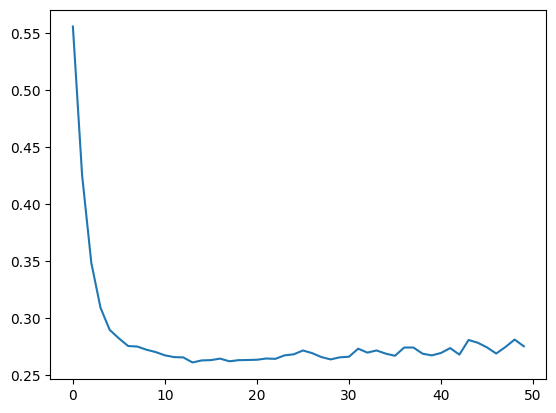

In [35]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])